In [154]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [155]:
data = pd.read_csv('dirty_cafe_sales.csv', sep=",")

In [131]:
data.shape

(10000, 8)

In [193]:
data.replace(['ERROR', 'UNKNOWN', ''], np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [194]:
num_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
data[num_cols] = data[num_cols].apply(pd.to_numeric, errors='coerce')

In [195]:
data.dtypes

Transaction ID          str
Item                    str
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
dtype: object

In [196]:
data.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [197]:
data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [198]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 10000


In [199]:
data_new = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((10000, 8), (3089, 8))

In [200]:
data_new.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03


In [201]:
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Quantity. Тип данных float64. Количество пустых значений 479, 4.79%.
Колонка Price Per Unit. Тип данных float64. Количество пустых значений 533, 5.33%.
Колонка Total Spent. Тип данных float64. Количество пустых значений 502, 5.02%.


In [202]:
data_num = data[num_cols]
data_num

,Quantity,Price Per Unit,Total Spent
0,2.0,2.0,4.0
1,4.0,3.0,12.0
2,4.0,1.0,NaN
3,2.0,5.0,10.0
4,2.0,2.0,4.0
...,...,...,...
9995,2.0,2.0,4.0
9996,3.0,NaN,3.0
9997,4.0,2.0,8.0
9998,3.0,NaN,3.0


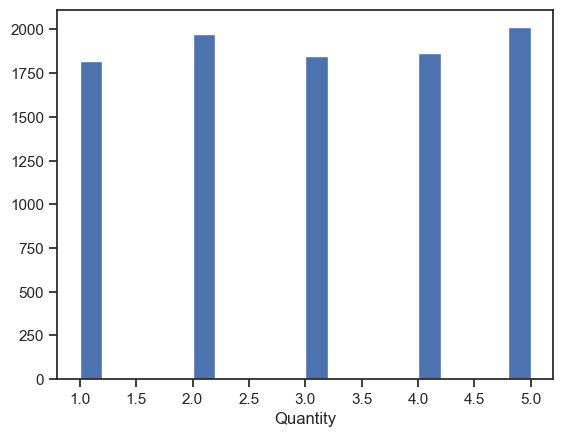

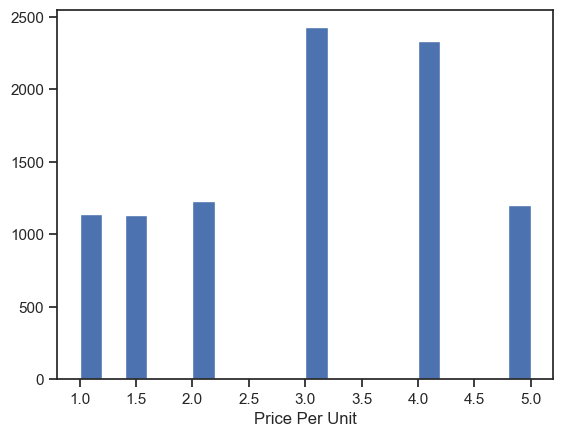

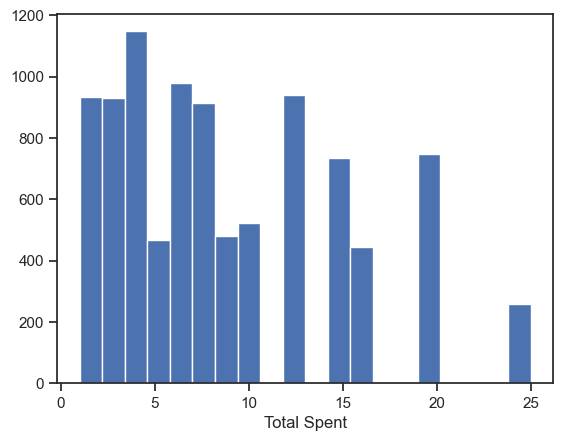

In [203]:
for col in data_num:
    plt.hist(data[col], 20)
    plt.xlabel(col)
    plt.show()

In [204]:
data_num_Quantity = data_num[['Quantity']]
data_num_Quantity.head()

,Quantity
0,2.0
1,4.0
2,4.0
3,2.0
4,2.0


In [205]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [206]:
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_Quantity)
mask_missing_values_only

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]], shape=(10000, 1))

In [207]:
strategies=['mean', 'median', 'most_frequent']

def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_Quantity)
    return data_num_imp[mask_missing_values_only]

In [208]:
strategies[0], test_num_impute(strategies[0])

('mean',
 array([3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634, 3.0284634,
        3.0284634, 3.0284634,

In [209]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
 

In [210]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.

In [211]:
data[['Price Per Unit']].describe()

,Price Per Unit
count,9467.000000
mean,2.949984
std,1.278450
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [212]:
data.shape

(10000, 8)

In [213]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

In [214]:
cat_cols = ['Transaction ID', 'Item', 'Payment Method', 'Location', 'Transaction Date']
print("ПРОПУСКИ В КАТЕГОРИАЛЬНЫХ КОЛОНКАХ:")
print("="*50)
for col in cat_cols:
    null_count = data[col].isnull().sum()
    null_percent = (null_count / len(data)) * 100
    print(f"{col}: {null_count} пропусков ({null_percent:.2f}%)")

ПРОПУСКИ В КАТЕГОРИАЛЬНЫХ КОЛОНКАХ:
Transaction ID: 0 пропусков (0.00%)
Item: 969 пропусков (9.69%)
Payment Method: 3178 пропусков (31.78%)
Location: 3961 пропусков (39.61%)
Transaction Date: 460 пропусков (4.60%)


In [215]:
#Я бы использовал Item, Payment Method и Location как категориальные признаки, Transaction Date преобразовал бы в день недели, час и месяц, Quantity, Price Per Unit и Total Spent как числовые признаки, а Transaction ID удалил бы как бесполезный уникальный идентификатор.

In [216]:
cat_temp_data = data[['Item']]
cat_temp_data.head()

,Item
0,Coffee
1,Cake
2,Cookie
3,Salad
4,Coffee


In [217]:
cat_temp_data['Item'].unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',        nan,
 'Sandwich',    'Juice',      'Tea']
Length: 9, dtype: str

In [218]:
cat_temp_data[cat_temp_data['Item'].isnull()].shape

(969, 1)

In [219]:
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2

array([['Coffee'],
       ['Cake'],
       ['Cookie'],
       ...,
       ['Coffee'],
       ['Cookie'],
       ['Sandwich']], shape=(10000, 1), dtype=object)

In [220]:
# Пустые значения отсутствуют
np.unique(data_imp2)

array(['Cake', 'Coffee', 'Cookie', 'Juice', 'Salad', 'Sandwich',
       'Smoothie', 'Tea'], dtype=object)

In [221]:
# Импьютация константой
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([['Coffee'],
       ['Cake'],
       ['Cookie'],
       ...,
       ['Coffee'],
       ['Cookie'],
       ['Sandwich']], shape=(10000, 1), dtype=object)

In [222]:
np.unique(data_imp3)

array(['Cake', 'Coffee', 'Cookie', 'Juice', 'NA', 'Salad', 'Sandwich',
       'Smoothie', 'Tea'], dtype=object)

In [223]:
data_imp3[data_imp3=='NA'].size

969

In [224]:
cat_enc = pd.DataFrame({'c1':data_imp2.T[0]})
cat_enc

,c1
0,Coffee
1,Cake
2,Cookie
3,Salad
4,Coffee
...,...
9995,Coffee
9996,Juice
9997,Coffee
9998,Cookie


In [225]:
from sklearn.preprocessing import LabelEncoder

In [226]:
cat_enc['c1'].unique()

<StringArray>
['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Juice', 'Sandwich', 'Tea']
Length: 8, dtype: str

In [227]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])

In [228]:
le.classes_

array(['Cake', 'Coffee', 'Cookie', 'Juice', 'Salad', 'Sandwich',
       'Smoothie', 'Tea'], dtype=object)

In [229]:
cat_enc_le

array([1, 0, 2, ..., 1, 2, 5], shape=(10000,))

In [230]:
np.unique(cat_enc_le)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [231]:
le.inverse_transform([0, 1, 2, 3])

array(['Cake', 'Coffee', 'Cookie', 'Juice'], dtype=object)

In [232]:
from sklearn.preprocessing import OrdinalEncoder
data_oe = data[['Item', 'Payment Method', 'Location']]
data_oe.head()

,Item,Payment Method,Location
0,Coffee,Credit Card,Takeaway
1,Cake,Cash,In-store
2,Cookie,Credit Card,In-store
3,Salad,NaN,NaN
4,Coffee,Digital Wallet,In-store


In [233]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['Coffee', 'Credit Card', 'Takeaway'],
       ['Cake', 'Cash', 'In-store'],
       ['Cookie', 'Credit Card', 'In-store'],
       ...,
       ['Coffee', 'Digital Wallet', 'NA'],
       ['Cookie', 'Digital Wallet', 'NA'],
       ['Sandwich', 'Cash', 'In-store']], shape=(10000, 3), dtype=object)

In [234]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[1., 1., 2.],
       [0., 0., 0.],
       [2., 1., 0.],
       ...,
       [1., 2., 1.],
       [2., 2., 1.],
       [6., 0., 0.]], shape=(10000, 3))

In [235]:
np.unique(cat_enc_oe[:, 0])

array([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [236]:
np.unique(cat_enc_oe[:, 1])

array([0., 1., 2., 3.])

In [237]:
np.unique(cat_enc_oe[:, 2])

array([0., 1., 2.])

In [238]:
oe.categories_

[array(['Cake', 'Coffee', 'Cookie', 'Juice', 'NA', 'Salad', 'Sandwich',
        'Smoothie', 'Tea'], dtype=object),
 array(['Cash', 'Credit Card', 'Digital Wallet', 'NA'], dtype=object),
 array(['In-store', 'NA', 'Takeaway'], dtype=object)]

In [239]:
oe.inverse_transform(cat_enc_oe)

array([['Coffee', 'Credit Card', 'Takeaway'],
       ['Cake', 'Cash', 'In-store'],
       ['Cookie', 'Credit Card', 'In-store'],
       ...,
       ['Coffee', 'Digital Wallet', 'NA'],
       ['Cookie', 'Digital Wallet', 'NA'],
       ['Sandwich', 'Cash', 'In-store']], shape=(10000, 3), dtype=object)

In [240]:
sizes = ['small', 'medium', 'large', 'small', 'medium', 'large', 'small', 'medium', 'large']

In [241]:
pd_sizes = pd.DataFrame(data={'sizes':sizes})
pd_sizes

,sizes
0,small
1,medium
2,large
3,small
4,medium
5,large
6,small
7,medium
8,large


In [242]:
pd_sizes['sizes_codes'] = pd_sizes['sizes'].map({'small':1, 'medium':2, 'large':3})
pd_sizes

,sizes,sizes_codes
0,small,1
1,medium,2
2,large,3
3,small,1
4,medium,2
5,large,3
6,small,1
7,medium,2
8,large,3


In [243]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

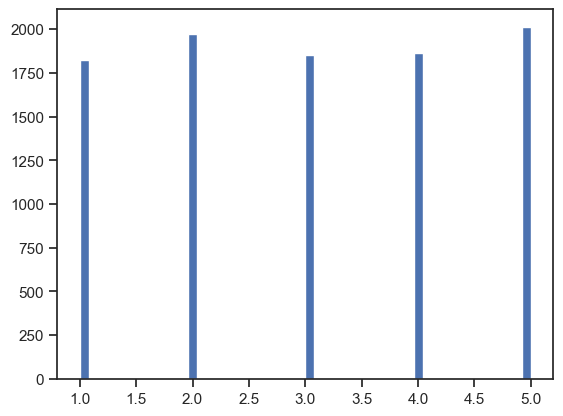

In [245]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Quantity']])
plt.hist(data['Quantity'], 50)
plt.show()

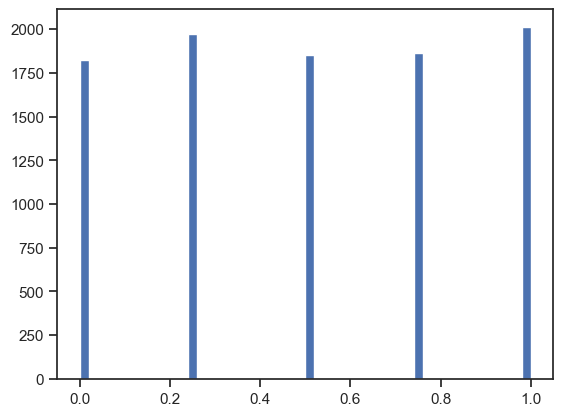

In [246]:
plt.hist(sc1_data, 50)
plt.show()

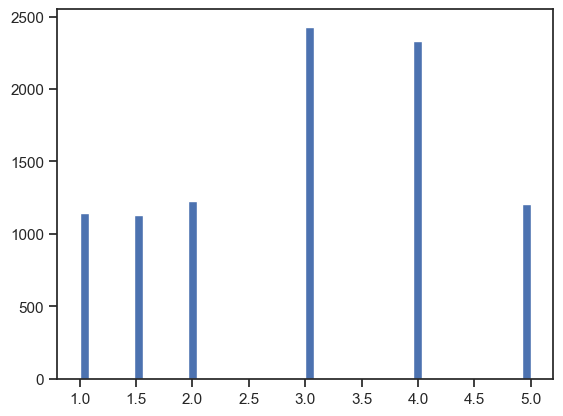

In [247]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Price Per Unit']])
plt.hist(data['Price Per Unit'], 50)
plt.show()

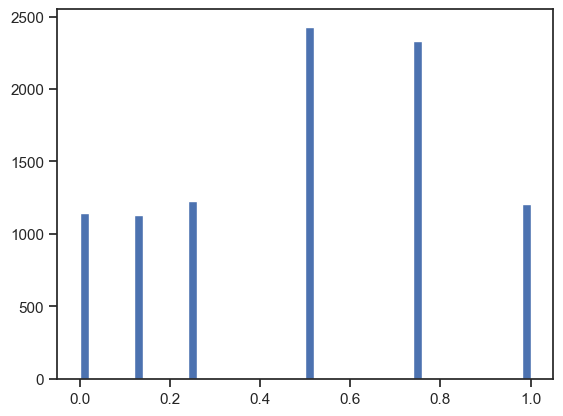

In [248]:
plt.hist(sc1_data, 50)
plt.show()

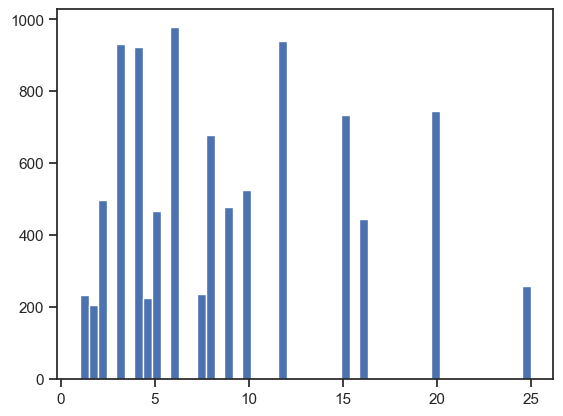

In [249]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Total Spent']])
plt.hist(data['Total Spent'], 50)
plt.show()

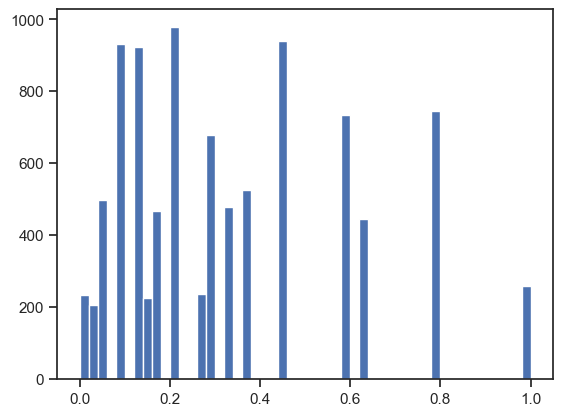

In [250]:
plt.hist(sc1_data, 50)
plt.show()

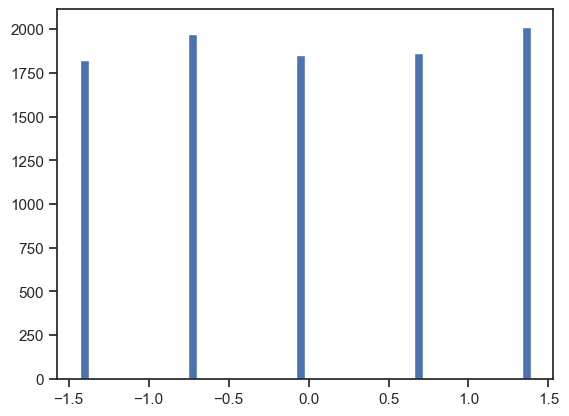

In [252]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Quantity']])
plt.hist(sc2_data, 50)
plt.show()

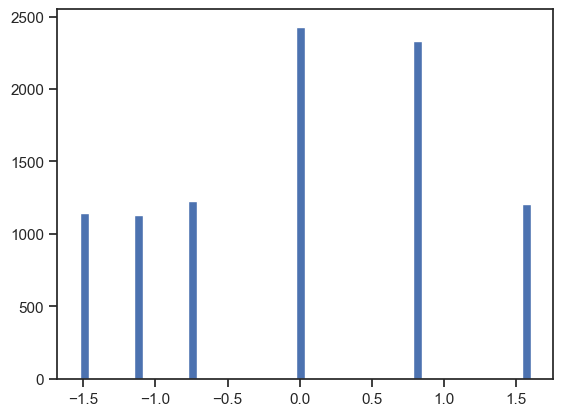

In [253]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Price Per Unit']])
plt.hist(sc2_data, 50)
plt.show()

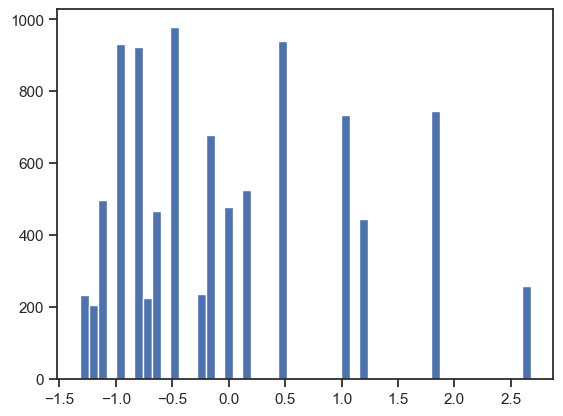

In [254]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Total Spent']])
plt.hist(sc2_data, 50)
plt.show()